Choose input method:
1 → Upload your own images
2 → Use sample stereo images
Enter 1 or 2: 1
Upload LEFT image first, then RIGHT image


Saving lab 10 crct.jpg to lab 10 crct.jpg
⚠️ Only one image uploaded → using same image (demo only)

Choose depth algorithm:
1 → StereoBM (basic)
2 → StereoSGBM (better quality)
Enter 1 or 2: 1


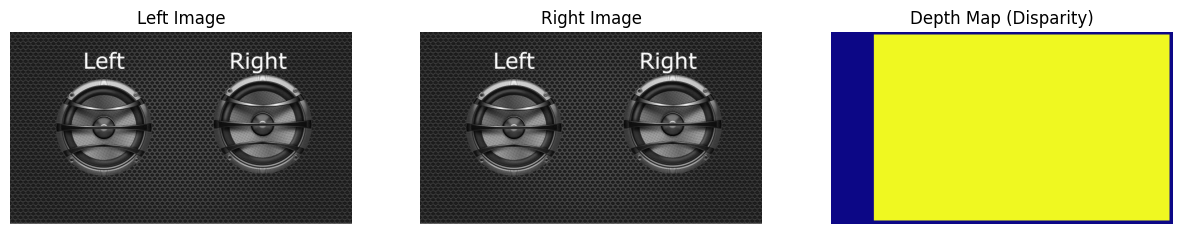

In [3]:
# =========================================
# 1. Install Required Libraries
# =========================================
!pip install opencv-python matplotlib -q

# =========================================
# 2. Import Libraries
# =========================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =========================================
# 3. Choose Input Method
# =========================================
print("Choose input method:")
print("1 → Upload your own images")
print("2 → Use sample stereo images")

choice = input("Enter 1 or 2: ")

# =========================================
# OPTION 1: Upload Images
# =========================================
if choice == '1':
    print("Upload LEFT image first, then RIGHT image")
    uploaded = files.upload()
    file_names = list(uploaded.keys())

    if len(file_names) == 0:
        raise Exception("No images uploaded!")

    elif len(file_names) == 1:
        # Duplicate for demo
        left_path = file_names[0]
        right_path = file_names[0]
        print("⚠️ Only one image uploaded → using same image (demo only)")

    else:
        left_path = file_names[0]
        right_path = file_names[1]

# =========================================
# OPTION 2: Use Sample Images
# =========================================
else:
    print("Downloading sample stereo images...")

    !wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeL.jpg
    !wget -q https://raw.githubusercontent.com/opencv/opencv/master/samples/data/aloeR.jpg

    left_path = "aloeL.jpg"
    right_path = "aloeR.jpg"

# =========================================
# 4. Read Images
# =========================================
left_img  = cv2.imread(left_path, 0)
right_img = cv2.imread(right_path, 0)

if left_img is None or right_img is None:
    raise Exception("Error loading images")

# =========================================
# 5. Choose Algorithm
# =========================================
print("\nChoose depth algorithm:")
print("1 → StereoBM (basic)")
print("2 → StereoSGBM (better quality)")

algo = input("Enter 1 or 2: ")

# =========================================
# 6. Create Stereo Object
# =========================================
if algo == '1':
    stereo = cv2.StereoBM_create(
        numDisparities=16*5,
        blockSize=15
    )
else:
    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16*6,
        blockSize=5
    )

# =========================================
# 7. Compute Disparity Map
# =========================================
disparity = stereo.compute(left_img, right_img)

# Normalize for visualization
disparity_norm = cv2.normalize(
    disparity, None, alpha=0, beta=255,
    norm_type=cv2.NORM_MINMAX
)

# =========================================
# 8. Display Results
# =========================================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.title("Left Image")
plt.imshow(left_img, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Right Image")
plt.imshow(right_img, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Depth Map (Disparity)")
plt.imshow(disparity_norm, cmap='plasma')
plt.axis("off")

plt.show()